# Discrete Choice Model Interpretation & Business Recommendations 

Estimated Time: 2-4 hours 

__Background__

At Astrea, we use discrete choice models to help clients make data-driven portfolio decisions. A 
common challenge is answering "sourcing" questions: for example, if a product is discontinued, 
where will its sales volume go? Or, stated differently, understand the cannibalization effect of 
introducing a new product in a category. 

Your task is to analyze the output of a simple discrete choice model, interpret its implications, 
and propose improvements to better address sourcing questions. 
You’ll be using an Multinomial Logit model, where the utility U for each item j, represented as: 

Uj = β0  + β1 X1j + β2 X2j + ⋯ + βk Xkj 

Where βn is the nth coefficient, and Xnj is the jth item’s nth characteristic. 
In order to estimate the βn, we collected data from respondents that are exposed to trips 
(subsets of items) and have to declare which of those items they would choose. 

__Dataset & Model Output__

You are provided with: 

1. Two CSV files containing the results of a multinomial logit (MNL) model, one the model 
coefficients and the other, the respondents data to exposure to trips of items. 

2. A short Python script to generate predictions.

__Tasks__

1. Model Interpretation 

- Examine the model coefficients and explain what they indicate about consumer 
preferences. 

- Identify any potential concerns or inconsistencies in the output (e.g., extreme 
coefficients, unrealistic substitution patterns).


2. Business Implications 

- Suppose our client is considering discontinuing Product X (choose any item). 
Based on the model results, where do you expect its sales volume to shift? 

- What additional analyses or model enhancements would you recommend to 
improve sourcing predictions? 

3. Technical Recommendations 

- What limitations does a standard MNL model have in answering sourcing 
questions? 

- Suggest a potential improvement 

__Deliverable__

Submit a brief Jupyter Notebook or Python script containing: 

- Your analysis and interpretations in markdown/text cells. 

- Any relevant exploratory code (e.g., visualizations, basic calculations).

---
---

# Deliverable

1.  Model Interpretation: 

Since the model is already trained there is not much to say about its coefficients besides its interpretation and a general observation concerning the algorithm.

1.1 _Algorithm_

As to the MNL model, the main issue with this kind of models is the Independence of irrelevant alternatives (IIA) axiom that is challanged in real life situations by menu effects or menu dependence. There are some other models that adress unperfect substitution like nested logit models and random effect ones. I'm sure there's a better algorithm out there, but I'm not well-versed in this subject.


1.2 _Coefficients_

As a general remark, since features are not scaled, this coefficients do not perfectly  describe their relative relevance but only the sign of the relationship to users preference (wethere it is direct + or indirect-) and intensity to a lesser extent.

+ const (Intercept)	-3.29	Baseline utility when all features are zero. A negative value means consumers generally have a low probability of choosing a product unless features like brand strength, quality, or price increase the utility.

+ price	-0.58	Negative coefficient → Higher prices reduce the likelihood of selection (as expected). The absolute value of 0.58 means price has a moderate impact on choice.

+ brand_strength	0.31	Positive coefficient → A stronger brand increases the probability of choice. Notwithstanding it's smaller than the quality effect (1.2) the average value for the feature brand_strenght is much lower, suggesting consumers care more about brand_strength than anything else.

+ quality_score	1.2	Strongest positive effect → Consumers prefer higher quality, and this is the dominant factor driving choice.



2. Business Implications 

2.1 Suppose our client is considering discontinuing Product X (choose any item). 
Based on the model results, where do you expect its sales volume to shift? 

- This is described below in the code. Demand is redistributed across other products weighting their relative market strength and the relevance of the features considered (quality, brand strength, price).
Unexpectedly, some products saw an absolute decrease in volume, but this can occur under these modeling assumptions. 

Products like 10 seem to be negatively affected by the removal of 5 from the market, whereas minor products like 2 are favoured by this change. I doubt this translates to real-world markets.

As to generalities, most demand shifts positively towards products 6,3,12,19 and 4; and some products are hurt by this change (10,13 and 15).


2.2 What additional analyses or model enhancements would you recommend to 
improve sourcing predictions? 

- There are almost no features capturing differences between products. This lacks depth and makes it harder to capture substitution issues across products that are very much different regardless of their price, quality and brand marketing. 

- I'm not knowledgable on this subject but I'd say that predictions should benefit by using some more sophisticated algorithms like nested logits, random effects,etc. If explainability can be neglected, other algorithms could provide some increase in forecasting quality (as is the case in many other cases).



3. Technical Recommendations 

- What limitations does a standard MNL model have in answering sourcing 
questions? 

As stated before, this models has assumptions that fail to adequately capture menu effects and imperfect substitution issues.
Ultimately, the market behavior is described in a weighted linear combination of factors. 

- Suggest a potential improvement 

Capturing trip_id and respondent_id as conditionals for the final marginal utility helps partially to adress issues with menu effects, but then again I'm not sure there are many relevant differences across trips.

If groups capture differences between this products or markets, a nested logit could be applied in this case.

Increasing variability of products betweeen trips could help gather customer preferences with more detail.DeprecationWarning




---
---

# Code

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('synthetic_choice_data.csv')
df.head()

,respondent_id,trip_id,product_id,price,brand_strength,quality_score,group,choice
0,0,0,13,2.911052,0.948886,4.579309,0,0
1,0,0,5,2.403951,0.785176,3.650089,0,0
2,0,0,7,8.795585,0.514234,3.080272,0,0
3,0,0,10,1.185260,0.607545,4.878339,0,1
4,0,0,12,8.491984,0.065052,4.757996,0,0


In [ ]:
coefs = pd.read_csv('logit_coefficients.csv')
coefs_dict = coefs.set_index("Variable")["Coefficient"].to_dict()
coefs = coefs.set_index('Variable').T
coefs.round(2)

Variable,const,price,brand_strength,quality_score
Coefficient,-3.29,-0.58,0.31,1.2


#### Prediction

In [ ]:
demand = pd.DataFrame(df.groupby('product_id').choice.sum()).sort_values(by='choice',ascending=False)
demand['share'] = np.round(demand.choice/demand.choice.sum()*100,2)
demand['cum_share'] = demand.share.cumsum()
demand

,choice,share,cum_share
product_id,,,
10,3438,22.92,22.92
15,2620,17.47,40.39
13,2548,16.99,57.38
5,1735,11.57,68.95
14,1540,10.27,79.22
3,815,5.43,84.65
6,682,4.55,89.20
4,455,3.03,92.23
19,332,2.21,94.44


In [ ]:
def compute_choice_probabilities(df, coefs):
    """Computes choice probabilities using a logit model."""
    df = df.copy()
    df["const"] = 1.0  # Add intercept
    
    # Compute utilities
    df["utility"] = (df["const"] * coefs.get("const", 0) +
                     df["price"] * coefs.get("price", 0) +
                     df["brand_strength"] * coefs.get("brand_strength", 0) +
                     df["quality_score"] * coefs.get("quality_score", 0))
    
    df["exp_utility"] = np.exp(df["utility"])
    
    # Compute choice probabilities
    df["choice_prob"] = df["exp_utility"] / df.groupby(["respondent_id", "trip_id"])["exp_utility"].transform("sum")
    return df

def redistribute_demand(df, discontinued_product_id):
    """Reallocates demand after removing a product."""
    df = df[df["product_id"] != discontinued_product_id].copy()  # Remove product
    df["choice_prob_new"] = df["exp_utility"] / df.groupby(["respondent_id", "trip_id"])["exp_utility"].transform("sum")
    
    return df.groupby("product_id")[["choice_prob_new"]].sum().rename(columns={"choice_prob_new": "redistributed_demand"})

# Compute initial probabilities
df = compute_choice_probabilities(df, coefs_dict)


In [ ]:
def redistribute_demand(df, discontinued_product_id):
    """Reallocates demand after removing a product."""
    df = df[df["product_id"] != discontinued_product_id].copy()  # Remove product
    df["choice_prob_new"] = df["exp_utility"] / df.groupby(["respondent_id", "trip_id"])["exp_utility"].transform("sum")
    
    return df.groupby("product_id")[["choice_prob_new"]].sum().rename(columns={"choice_prob_new": "redistributed_demand"})

# Load model coefficients (assumed preloaded)
coefs = {"const": -3.29, "price": -0.58, "brand_strength": 0.31, "quality_score": 1.2}

# Compute initial probabilities
df = compute_choice_probabilities(df, coefs)

In [85]:
# Choose a product to discontinue (e.g., product_id = 5)
discontinued_product = 5
demand_shift = redistribute_demand(df, discontinued_product)

demand_shift.round(1)


,redistributed_demand
product_id,
0,178.0
1,47.3
2,18.3
3,1064.5
4,663.9
6,1033.8
7,93.5
8,369.1
9,39.6


In [ ]:
df_shifted = pd.concat([demand_shift,pd.DataFrame(df.groupby("product_id").choice.sum())],axis=1).round(0)
df_shifted['redistributed_demand'] = df_shifted['redistributed_demand'].fillna(0).astype(int)
df_shifted['delta'] = df_shifted.redistributed_demand - df_shifted.choice
df_shifted['delta_%'] = (df_shifted.delta / df_shifted.choice-1).round(2)
df_shifted['share'] = (df_shifted.choice / df_shifted.choice.sum()).round(2)
df_shifted['delta_share'] = (df_shifted.delta / df_shifted[df_shifted.index==5].choice.values).round(2)
df_shifted.sort_values(by='delta_share',ascending=False)

,redistributed_demand,choice,delta,delta_%,share,delta_share
product_id,,,,,,
6,1034,682,352,-0.48,0.05,0.20
3,1065,815,250,-0.69,0.05,0.14
12,526,293,233,-0.20,0.02,0.13
19,539,332,207,-0.38,0.02,0.12
4,664,455,209,-0.54,0.03,0.12
8,369,216,153,-0.29,0.01,0.09
16,200,78,122,0.56,0.01,0.07
11,155,53,102,0.92,0.00,0.06
17,103,16,87,4.44,0.00,0.05


In [146]:
grouped_df = df.groupby('product_id').agg({'choice': 'sum',
                              'price': 'mean',
                              'brand_strength': 'mean',
                              'quality_score': 'mean',
                              }).round(1).sort_values(by='brand_strength',ascending=True)
grouped_df 

,choice,price,brand_strength,quality_score
product_id,,,,
9,2,7.4,0.0,1.7
1,3,9.6,0.1,3.0
17,16,5.7,0.1,1.8
12,293,8.5,0.1,4.8
6,682,1.5,0.2,2.2
11,53,9.7,0.2,4.1
2,2,7.6,0.3,1.1
16,78,3.7,0.3,1.4
19,332,3.6,0.4,2.3


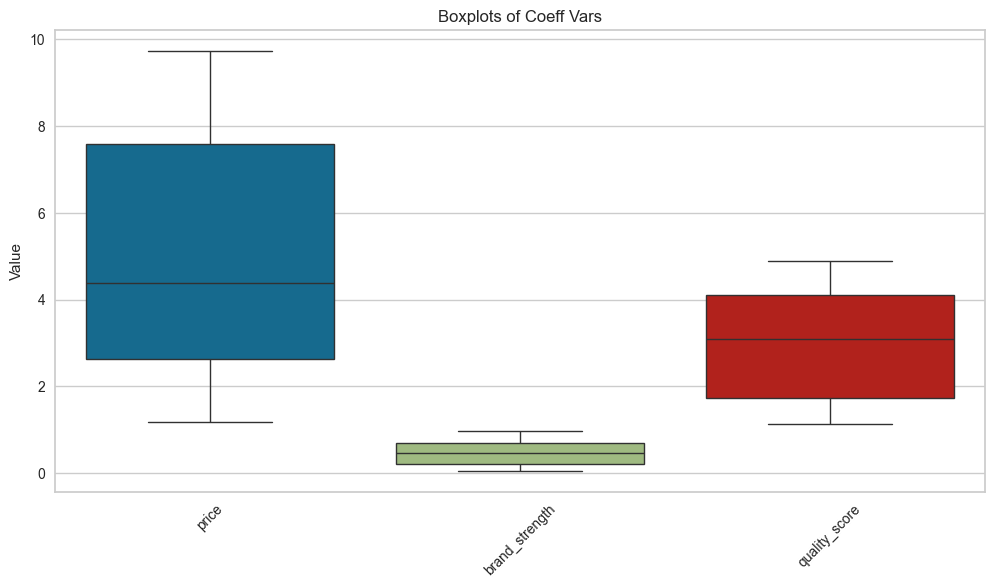

In [ ]:
# Exclude non-numeric columns (if any)
numeric_cols = df[['price', 'brand_strength', 'quality_score']]
# Create the boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=numeric_cols)

# Customize plot labels
plt.xticks(rotation=45)  # Rotate labels for readability
plt.title("Boxplots of Coeff Vars")
plt.ylabel("Value")

# Show the plot
plt.show()


In [ ]:
# toy script
%run take-home-predict.py

   product_id  predicted_choice_prob
0           1               0.152508
1           2               0.315033
2           3               0.033762
3           4               0.102532
4           5               0.396165
